2026-04-23 14:58:29.424044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776927509.454025   10008 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776927509.462780   10008 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 14:58:29.494359: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



===== Training FLUID =====


2026-04-23 14:58:36.543521: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/waleed/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 216 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Training ContiFormer =====


/home/waleed/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 52 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Training ODEFormer =====


/home/waleed/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Training OTTransformer =====

===== Training SDPA =====


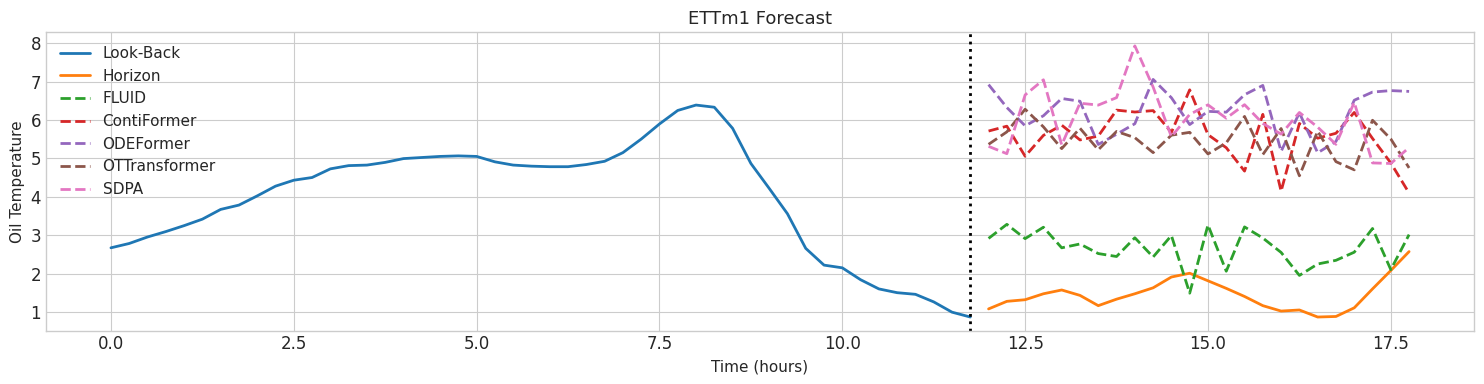

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from keras._tf_keras.keras.layers import GlobalAveragePooling1D, Activation, Dense, Input
from keras._tf_keras.keras.optimizers import AdamW
from keras._tf_keras.keras.models import Model
from keras._tf_keras.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler

from FLUID import FLUID
from baseline_cells import SPDATransformer, ContiFormer, OTTransformer, ODEformer

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 3,
})


LOOKBACK = 48      
HORIZON = 24      
BATCH_SIZE = 64
EPOCHS = 50
TARGET_COL = 'OT'

WEIGHTS_DIR = 'model_weights4'
BASE_MODEL_NAME = 'ETTm1_forecast'
os.makedirs(WEIGHTS_DIR, exist_ok=True)

MODEL_LIST = ["FLUID","ContiFormer", "ODEFormer", "OTTransformer", "SDPA"]


def prepare_ettm1_data(file_path):
    df = pd.read_csv(file_path)
    df = df.iloc[:25000]
    
    features = df.drop(columns=['date'])
    n_features = features.shape[1]    
    n = len(features)
    train_df = features[0:int(n*0.8)]
    val_df = features[int(n*0.8):int(n*0.9)]
    test_df = features[int(n*0.9):]
    scaler = MinMaxScaler()
    scaler.fit(train_df)
    
    train_s = scaler.transform(train_df)
    val_s = scaler.transform(val_df)
    test_s = scaler.transform(test_df)

    def create_windows(data):
        X, y = [], []
        for i in range(len(data) - LOOKBACK - HORIZON):
            X.append(data[i : i + LOOKBACK, :]) # All features
            y.append(data[i + LOOKBACK : i + LOOKBACK + HORIZON, -1]) # Target (OT)
        return np.array(X), np.array(y)

    X_train, y_train = create_windows(train_s)
    X_val, y_val = create_windows(val_s)
    X_test, y_test = create_windows(test_s)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler, n_features


def inverse_temp(scaled_vals, scaler):
    dummy = np.zeros((len(scaled_vals), scaler.n_features_in_))
    dummy[:, -1] = scaled_vals  # target column
    return scaler.inverse_transform(dummy)[:, -1]

def plot_forecasts(num_samples=5, start_idx=0):
    time_axis = np.arange(LOOKBACK + HORIZON)* 0.25
    idxs = list(range(start_idx, start_idx + num_samples))
    history = np.mean([inverse_temp(X_test[i][:, -1], scaler) for i in idxs],axis=0)
    true = np.mean([inverse_temp(y_test[i], scaler) for i in idxs],axis=0)

    avg_preds = {}

    for name in MODEL_LIST:
        avg_preds[name] = np.mean([inverse_temp(preds[name][i], scaler) for i in idxs],axis=0)

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis[:LOOKBACK], history, label="Look-Back", linewidth=2)
    plt.plot(time_axis[LOOKBACK:], true, label="Horizon", linewidth=2)

    for name in MODEL_LIST:
        plt.plot(time_axis[LOOKBACK:],avg_preds[name],linestyle="--",linewidth=2,label=name)

    plt.axvline(time_axis[LOOKBACK - 1], color="black", linestyle=":")
    plt.title(f"ETTm1 Forecast")
    plt.xlabel("Time (hours)")
    plt.ylabel("Oil Temperature")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def build_model(name, input_shape):
    inp = Input(shape=input_shape)

    if name == "FLUID":
        x = FLUID(d_model=64, num_heads=4, ff_dim=64,topk=32, euler_steps=5, num_layers=1, max_len=96)(inp)
    elif name == "ContiFormer":
        x = Dense(64)(inp)
        x = ContiFormer(dim=64, num_heads=4, ff_dim=64)(x)
    elif name == "ODEFormer":
        x = ODEformer(hidden_dim=64, num_heads=4, ff_dim=64)(inp)
    elif name == "OTTransformer":
        x = OTTransformer(key_dim=64, num_heads=4, ff_dim=64)(inp)
    elif name == "SDPA":
        x = SPDATransformer(embed_dim=64, num_heads=4, ff_dim=64)(inp)
    else:
        raise ValueError(f"Unknown model name: {name}")

    x = Activation('relu')(x)
    x = GlobalAveragePooling1D()(x)
    out = Dense(HORIZON)(x)

    model = Model(inp, out)
    model.compile(optimizer=AdamW(1e-4), loss='mse', metrics=['mae'])
    return model


X_train, y_train, X_val, y_val, X_test, y_test, scaler, n_feats = prepare_ettm1_data('ETTm1.csv')
results = {}
preds = {}

for name in MODEL_LIST:
    print(f"\n===== Training {name} =====")

    model = build_model(name, (LOOKBACK, n_feats))

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
        ModelCheckpoint(f"{WEIGHTS_DIR}/{BASE_MODEL_NAME}_{name}.keras",monitor='val_loss',save_best_only=True)
    ]

    # history = model.fit(
    #     X_train, y_train,
    #     validation_data=(X_val, y_val),
    #     epochs=EPOCHS,
    #     batch_size=BATCH_SIZE,
    #     callbacks=callbacks,
    #     verbose=1
    # )

    model.load_weights(f"{WEIGHTS_DIR}/{BASE_MODEL_NAME}_{name}.keras")
    preds[name] = model.predict(X_test, verbose=0)


plot_forecasts(num_samples=5, start_idx=100)

2026-04-23 15:02:27.041590: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776927747.077083   10549 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776927747.087050   10549 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 15:02:27.122104: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



===== Training FLUID =====


2026-04-23 15:02:33.916619: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/waleed/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 216 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Training ContiFormer =====


/home/waleed/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 52 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Training ODEFormer =====


/home/waleed/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



===== Training OTTransformer =====

===== Training SDPA =====


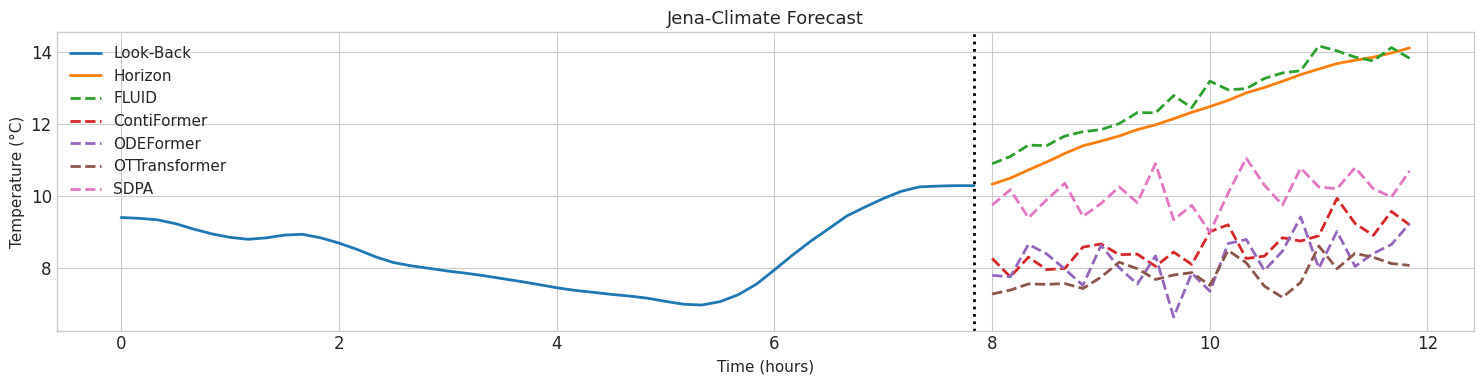

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from keras._tf_keras.keras.layers import GlobalAveragePooling1D, Activation, Dense, Input
from keras._tf_keras.keras.optimizers import AdamW
from keras._tf_keras.keras.models import Model
from keras._tf_keras.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler

from FLUID import FLUID
from baseline_cells import SPDATransformer, ContiFormer, OTTransformer, ODEformer

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 3,
})


LOOKBACK = 48
HORIZON = 24
BATCH_SIZE = 64
EPOCHS = 50
TARGET_COL = 'T (degC)'

WEIGHTS_DIR = 'model_weights4'
BASE_MODEL_NAME = 'Weather_forecast'
os.makedirs(WEIGHTS_DIR, exist_ok=True)

MODEL_LIST = ["FLUID","ContiFormer", "ODEFormer", "OTTransformer", "SDPA"]


def prepare_weather_data(file_path):
    df = pd.read_csv(file_path)
    df = df.iloc[:25000]
    features = df.drop(columns=['Date Time'])
    cols = [c for c in features.columns if c != TARGET_COL] + [TARGET_COL]
    features = features[cols]
    n_features = features.shape[1]

    n = len(features)
    train_df = features[:int(n*0.8)]
    val_df = features[int(n*0.8):int(n*0.9)]
    test_df = features[int(n*0.9):]

    scaler = MinMaxScaler()
    scaler.fit(train_df)

    train_s = scaler.transform(train_df)
    val_s = scaler.transform(val_df)
    test_s = scaler.transform(test_df)

    def create_windows(data):
        X, y = [], []
        for i in range(len(data) - LOOKBACK - HORIZON):
            X.append(data[i:i+LOOKBACK, :])
            y.append(data[i+LOOKBACK:i+LOOKBACK+HORIZON, -1])
        return np.array(X), np.array(y)

    X_train, y_train = create_windows(train_s)
    X_val, y_val = create_windows(val_s)
    X_test, y_test = create_windows(test_s)
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler, n_features


def inverse_temp(scaled_vals, scaler):
    dummy = np.zeros((len(scaled_vals), scaler.n_features_in_))
    dummy[:, -1] = scaled_vals  # target column
    return scaler.inverse_transform(dummy)[:, -1]

def plot_forecasts(num_samples=5, start_idx=0):
    time_axis = np.arange(LOOKBACK + HORIZON) * 0.1667
    idxs = list(range(start_idx, start_idx + num_samples))
    history = np.mean([inverse_temp(X_test[i][:, -1], scaler) for i in idxs],axis=0)
    true = np.mean([inverse_temp(y_test[i], scaler) for i in idxs],axis=0)

    avg_preds = {}

    for name in MODEL_LIST:
        avg_preds[name] = np.mean([inverse_temp(preds[name][i], scaler) for i in idxs],axis=0)

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis[:LOOKBACK], history, label="Look-Back", linewidth=2)
    plt.plot(time_axis[LOOKBACK:], true, label="Horizon", linewidth=2)

    for name in MODEL_LIST:
        plt.plot(time_axis[LOOKBACK:],avg_preds[name],linestyle="--",linewidth=2,label=name)

    plt.axvline(time_axis[LOOKBACK - 1], color="black", linestyle=":")
    plt.title(f"Jena-Climate Forecast")
    plt.xlabel("Time (hours)")
    plt.ylabel("Temperature (°C)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def build_model(name, input_shape):
    inp = Input(shape=input_shape)

    if name == "FLUID":
        x = FLUID(d_model=64, num_heads=4, ff_dim=64,topk=32, euler_steps=5, num_layers=1, max_len=96)(inp)
    elif name == "ContiFormer":
        x = Dense(64)(inp)
        x = ContiFormer(dim=64, num_heads=4, ff_dim=64)(x)
    elif name == "ODEFormer":
        x = ODEformer(hidden_dim=64, num_heads=4, ff_dim=64)(inp)
    elif name == "OTTransformer":
        x = OTTransformer(key_dim=64, num_heads=4, ff_dim=64)(inp)
    elif name == "SDPA":
        x = SPDATransformer(embed_dim=64, num_heads=4, ff_dim=64)(inp)
    else:
        raise ValueError(f"Unknown model name: {name}")

    x = Activation('relu')(x)
    x = GlobalAveragePooling1D()(x)
    out = Dense(HORIZON)(x)

    model = Model(inp, out)
    model.compile(optimizer=AdamW(1e-4), loss='mse', metrics=['mae'])
    return model


X_train, y_train, X_val, y_val, X_test, y_test, scaler, n_feats = prepare_weather_data('weather.csv')
results = {}
preds = {}

for name in MODEL_LIST:
    print(f"\n===== Training {name} =====")

    model = build_model(name, (LOOKBACK, n_feats))

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
        ModelCheckpoint(f"{WEIGHTS_DIR}/{BASE_MODEL_NAME}_{name}.keras",monitor='val_loss',save_best_only=True)
    ]

    # history = model.fit(
    #     X_train, y_train,
    #     validation_data=(X_val, y_val),
    #     epochs=EPOCHS,
    #     batch_size=BATCH_SIZE,
    #     callbacks=callbacks,
    #     verbose=1
    # )

    
    model.load_weights(f"{WEIGHTS_DIR}/{BASE_MODEL_NAME}_{name}.keras")
    preds[name] = model.predict(X_test, verbose=0)


plot_forecasts(num_samples=5, start_idx=100)